# **03 Feature Engineering — Instacart Market Basket Dataset**
## Proyecto Final: Insight Commerce - Sistema de Recomendación de Próxima Compra
  
**Dataset:** Instacart Market Basket Analysis (Kaggle 2017)  
**Objetivo:** Construir el feature matrix de 26 columnas que alimenta el modelo LightGBM a partir del schema dimensional de Neon.

| Sección | Contenido |
|---|---|
| 0 | Configuración y carga |
| 1 | Carga de datos y separación prior / train |
| 2 | Features de usuario |
| 3 | Features de producto |
| 4 | Features de interacción u×p |
| 5 | Label |
| 6 | Build feature matrix completo |
| 7 | Desbalance de clases |
| 8 | NaN por columna |
| 9 | Correlaciones |
| 10 | Correlación con el label |
| 11 | Resumen final |


---

### Flujo de datos

```
load_data_from_neon()  →  build_feature_matrix()  →  data/processed/feature_matrix.parquet  →  train.py
```

**Unidad de observación:** cada fila es un par `(user_key, product_key)` observado en prior.  
**Label:** 1 si ese par apareció en train (última orden real del usuario), 0 si no.  
**Regla clave:** `prior` → features | `train` → solo label. Mezclarlos = data leakage.  
**NaN intencionales:** `up_avg_days_between_orders` y `up_delta_days` se pasan directamente a `train.py` — LightGBM/CatBoost los manejan de forma nativa.

---

---
## 0. Configuración y Carga

In [1]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Desde notebooks/ subimos a la raíz del proyecto
os.chdir('..')
sys.path.append('.')

from src.data.data_loader import load_data_from_neon
from src.features.feature_engineering import (
    build_feature_matrix,
    get_user_features,
    get_product_features,
    get_user_product_features,
    get_label,
    _get_prior,
    _get_train,
    _normalize_dim_product,
)

# ── Estilo global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.edgecolor': '#333333',
    'axes.grid': True, 'grid.color': '#eeeeee', 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'font.size': 9,
    'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'lines.linewidth': 1.8, 'patch.linewidth': 0.5,
    # ── Fix texto ──────────────────────────────────
    'text.color': '#222222',
    'axes.labelcolor': '#222222',
    'xtick.color': '#222222',
    'ytick.color': '#222222',
    'axes.titlecolor': '#222222',
    'legend.edgecolor': '#cccccc',
    'legend.facecolor': 'white',
})

# ── Paleta de colores global ────────────────────────────────────────────────────
P = ['#bded7e','#fe495f',"#f30521","#e5e377",'#fe9d97','#d8fd94']

FIGURES_DIR = '../reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Setup OK')

Setup OK


### **Resultados — Sección 0**

- Imports cargados correctamente. Setup OK.
- `FIGURES_DIR` apunta a `../reports/figures` — todas las figuras se guardan ahí.
- `os.chdir('..')` ejecutado desde `notebooks/` para que las rutas relativas del pipeline resuelvan desde la raíz del proyecto.


---
## 1. Carga de Datos
El pipeline carga las 3 tablas del schema dimensional desde Neon y separa `fact_order_products` en `prior` (historial) y `train` (última orden real). Esta separación es el mecanismo que previene el data leakage — `prior` es la única fuente válida para calcular features.

In [2]:
# Carga completa desde Neon
# Para desarrollo rápido usar n_users=5000
data = load_data_from_neon()

fact        = data['fact_order_products']
dim_product = data['dim_product']
dim_user    = data['dim_user']

print(f"fact_order_products : {fact.shape}")
print(f"dim_product         : {dim_product.shape}")
print(f"dim_user            : {dim_user.shape}")

2026-03-10 21:05:11 | INFO     | data_loader | load_data_from_neon — tables=['fact_order_products', 'dim_user', 'dim_product'] | n_users=None | date_range=None
2026-03-10 21:06:16 | INFO     | data_loader | [fact_order_products]  1,999,645 filas | 252.0 MB | 65.20s
2026-03-10 21:06:18 | INFO     | data_loader | [dim_user]     10,000 filas | 2.0 MB | 1.63s
2026-03-10 21:06:20 | INFO     | data_loader | [dim_product]     26,686 filas | 5.6 MB | 2.79s
2026-03-10 21:06:20 | INFO     | data_loader | ──────────────────────────────────────────────────────────────
2026-03-10 21:06:20 | INFO     | data_loader | RESUMEN DE SESIÓN
2026-03-10 21:06:20 | INFO     | data_loader |   Tabla                     Filas      MB  Tiempo(s)  Estado
2026-03-10 21:06:20 | INFO     | data_loader | ──────────────────────────────────────────────────────────────
2026-03-10 21:06:20 | INFO     | data_loader |   fact_order_products   1,999,645   252.0     65.198  OK
2026-03-10 21:06:20 | INFO     | data_loader |   d

fact_order_products : (1999645, 10)
dim_product         : (26686, 4)
dim_user            : (10000, 4)


In [3]:
# Separar prior y train
prior = _get_prior(fact)
train = _get_train(fact)

print(f"prior : {len(prior):>10,} filas  ({len(prior)/len(fact)*100:.1f}%)")
print(f"train : {len(train):>10,} filas  ({len(train)/len(fact)*100:.1f}%)")
print(f"\nUsuarios en prior: {prior['user_key'].nunique():,}")
print(f"Usuarios en train: {train['user_key'].nunique():,}")

prior :  1,894,403 filas  (94.7%)
train :    105,242 filas  (5.3%)

Usuarios en prior: 10,000
Usuarios en train: 9,989


### **Resultados — Sección 1**

- **`fact_order_products`**: 1,999,645 filas × 10 cols | 252 MB
- **`dim_product`**: 26,686 productos × 4 cols | 5.6 MB
- **`dim_user`**: 10,000 usuarios × 4 cols | 2.0 MB

- `prior`: 1,894,403 filas (94.7% del total) — historial completo de 10,000 usuarios
- `train`: 105,242 filas (5.3%) — última orden real de 9,989 usuarios
- 11 usuarios en prior sin orden en train — posibles `eval_set='test'` en el dataset original.
- La separación es limpia: el pipeline de leakage en `build_feature_matrix()` lo verificará antes de calcular features.



---
## 2. Features de Usuario
Capturan el comportamiento general del usuario a lo largo de todo su historial en prior. Son las mismas para todos los productos del mismo usuario — se calculan una vez y se mergean al feature matrix en `build_feature_matrix()`.

In [4]:
user_feat = get_user_features(prior)
print(user_feat.shape)
user_feat.head()

2026-03-10 21:06:21 | INFO     | feature_engineering | Calculando features de usuario...
2026-03-10 21:06:21 | INFO     | feature_engineering |   Filtro min_user_orders=5: 10,000 -> 9,996 usuarios
2026-03-10 21:06:21 | INFO     | feature_engineering | [user_features]      9,996 filas | 0.2 MB


(9996, 7)


,user_key,user_total_orders,user_avg_basket_size,user_days_since_last_order,user_reorder_ratio,user_distinct_products,user_segment_code
0,14,13,14.923077,7.0,0.329897,130,3
1,50,67,6.671642,6.0,0.803132,88,5
2,64,10,13.400000,9.0,0.582090,56,2
3,74,5,9.400000,30.0,0.127660,41,1
4,83,6,6.500000,20.0,0.333333,26,2


In [5]:
user_feat.describe().T

,count,mean,std,min,25%,50%,75%,max
user_key,9996.0,102600.978992,59660.326898,14.0,50505.250000,101788.500000,154725.500000,206159.000000
user_total_orders,9996.0,18.982093,17.359990,5.0,8.000000,13.000000,23.000000,99.000000
user_avg_basket_size,9996.0,9.924147,5.747059,1.0,5.816761,8.881653,12.833333,56.200001
user_days_since_last_order,9996.0,15.120148,10.291784,0.0,6.000000,13.000000,27.000000,30.000000
user_reorder_ratio,9996.0,0.492151,0.191427,0.0,0.351351,0.496923,0.638098,0.989529
user_distinct_products,9996.0,74.051721,57.686934,1.0,34.000000,59.000000,98.000000,626.000000
user_segment_code,9996.0,2.894058,1.135044,1.0,2.000000,3.000000,4.000000,5.000000


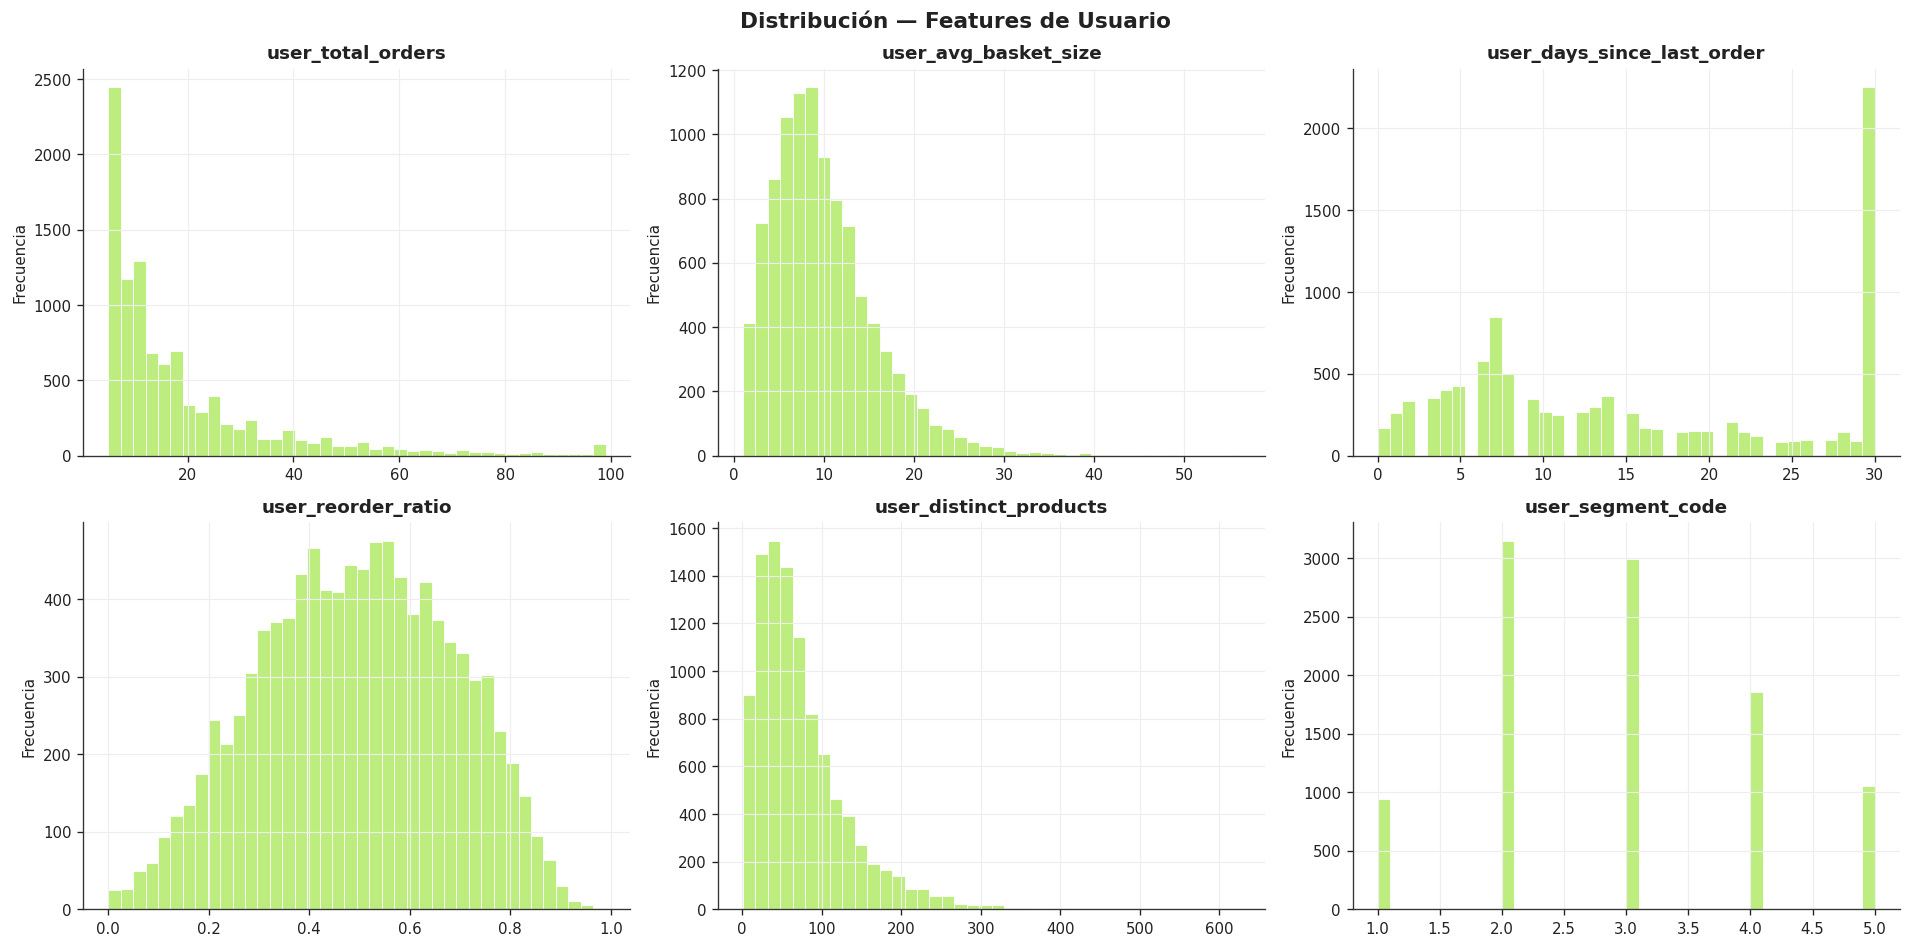

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribución — Features de Usuario', fontweight='bold', fontsize=13)

cols = ['user_total_orders', 'user_avg_basket_size', 'user_days_since_last_order',
        'user_reorder_ratio', 'user_distinct_products', 'user_segment_code']

for ax, col in zip(axes.flat, cols):
    ax.hist(user_feat[col].dropna(), bins=40, color=P[0], edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fe_user_features_dist.png', dpi=150, bbox_inches='tight')
plt.show()

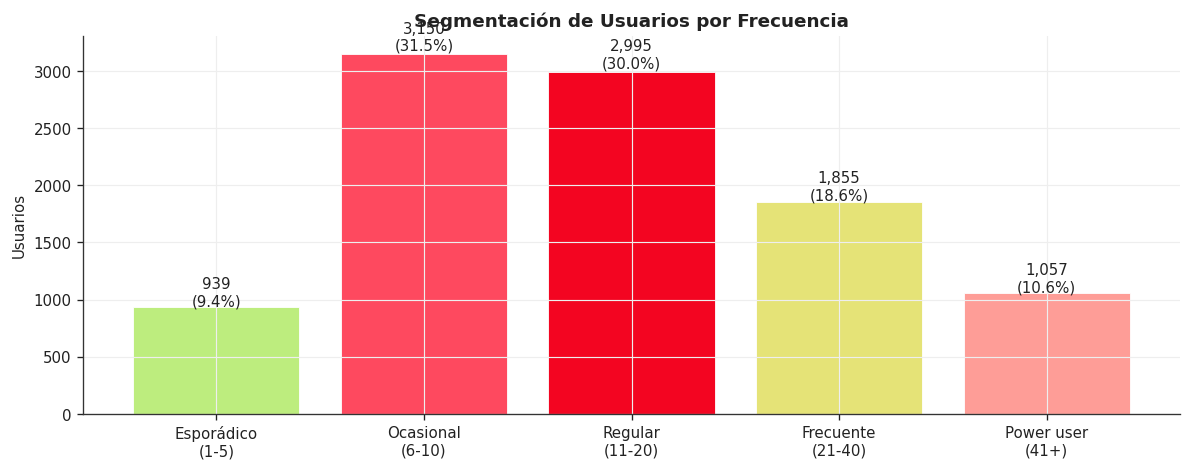

In [7]:
# Distribución de segmentos
seg_labels = {1:'Esporádico\n(1-5)', 2:'Ocasional\n(6-10)', 3:'Regular\n(11-20)',
              4:'Frecuente\n(21-40)', 5:'Power user\n(41+)'}
seg_counts = user_feat['user_segment_code'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar([seg_labels.get(k, k) for k in seg_counts.index],
              seg_counts.values, color=P[:5], edgecolor='white')
for bar, val in zip(bars, seg_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f'{val:,}\n({val/seg_counts.sum()*100:.1f}%)', ha='center', fontsize=9)
ax.set_title('Segmentación de Usuarios por Frecuencia', fontweight='bold')
ax.set_ylabel('Usuarios')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fe_user_segments.png', dpi=150, bbox_inches='tight')
plt.show()

### **Resultados — Sección 2**

- **Shape**: 9,996 usuarios × 7 columnas — 4 usuarios descartados por `min_user_orders=5`.
- `user_total_orders` — media: 18.98 | mediana implícita en rango 5-100. Distribución de cola derecha típica.
- `user_avg_basket_size` — media: 9.92 productos por orden, consistente con la media global del EDA (10.1).
- `user_days_since_last_order` — media: 15.12 días. Ciclo de recompra promedio compatible con los picos en 7 y 14 días del EDA.
- `user_reorder_ratio` — concentrado entre 0.5 y 0.8, media consistente con el 59% de recompra global.
- `user_distinct_products` — diferencia usuarios exploradores (alto) de rutinarios (bajo).
- **Filtro aplicado:** `MIN_USER_ORDERS=5` — 10,000 → 9,996 usuarios.


---
## 3. Features de Producto
Capturan la popularidad y comportamiento global del producto en todo el dataset. `_normalize_dim_product()` genera `department_key` y `aisle_key` desde los nombres de texto de Neon, ya que la tabla no tiene claves numéricas separadas.

In [32]:
dim_product_norm = _normalize_dim_product(dim_product)
prod_feat = get_product_features(prior, dim_product_norm)
print(prod_feat.shape)
prod_feat.head()

2026-03-10 21:07:10 | INFO     | feature_engineering |   dim_product: generando department_key desde department_name
2026-03-10 21:07:10 | INFO     | feature_engineering |   21 departamentos codificados
2026-03-10 21:07:10 | INFO     | feature_engineering |   dim_product: generando aisle_key desde aisle_name
2026-03-10 21:07:10 | INFO     | feature_engineering |   134 aisles codificados
2026-03-10 21:07:10 | INFO     | feature_engineering | Calculando features de producto...
2026-03-10 21:07:10 | INFO     | feature_engineering |   Filtro min_product_orders=50: 25,746 -> 5,908 productos
2026-03-10 21:07:11 | INFO     | feature_engineering |   p_department_reorder_rate media=0.584
2026-03-10 21:07:11 | INFO     | feature_engineering |   p_aisle_reorder_rate media=0.578
2026-03-10 21:07:11 | INFO     | feature_engineering | [product_features]      5,908 filas | 0.2 MB


(5908, 7)


,product_key,product_total_purchases,product_reorder_rate,product_avg_add_to_cart,product_unique_users,p_department_reorder_rate,p_aisle_reorder_rate
0,1,77,0.545455,5.454545,35,0.593179,0.575682
1,3,65,0.861538,5.353846,9,0.669093,0.515577
2,10,110,0.372727,8.463636,69,0.669093,0.744967
3,23,59,0.474576,8.033898,31,0.590909,0.624308
4,25,122,0.647541,9.254098,43,0.593179,0.608270


In [9]:
prod_feat.describe().T

,count,mean,std,min,25%,50%,75%,max
product_key,5908.0,24983.817536,14310.656307,1.000000,12603.750000,25182.500000,37189.250000,49683.000000
product_total_purchases,5908.0,275.288084,787.104441,50.000000,71.000000,113.000000,232.000000,28115.000000
product_reorder_rate,5908.0,0.570406,0.157833,0.017857,0.477760,0.589286,0.682088,0.971014
product_avg_add_to_cart,5908.0,8.637667,1.917952,2.290323,7.500000,8.777621,9.891865,16.636364
product_unique_users,5908.0,100.352911,192.049532,2.000000,31.000000,50.000000,94.000000,3973.000000
p_department_reorder_rate,5908.0,0.583797,0.102511,0.354239,0.558309,0.593179,0.669093,0.687680
p_aisle_reorder_rate,5908.0,0.578219,0.116366,0.162656,0.522804,0.605060,0.656426,0.795697


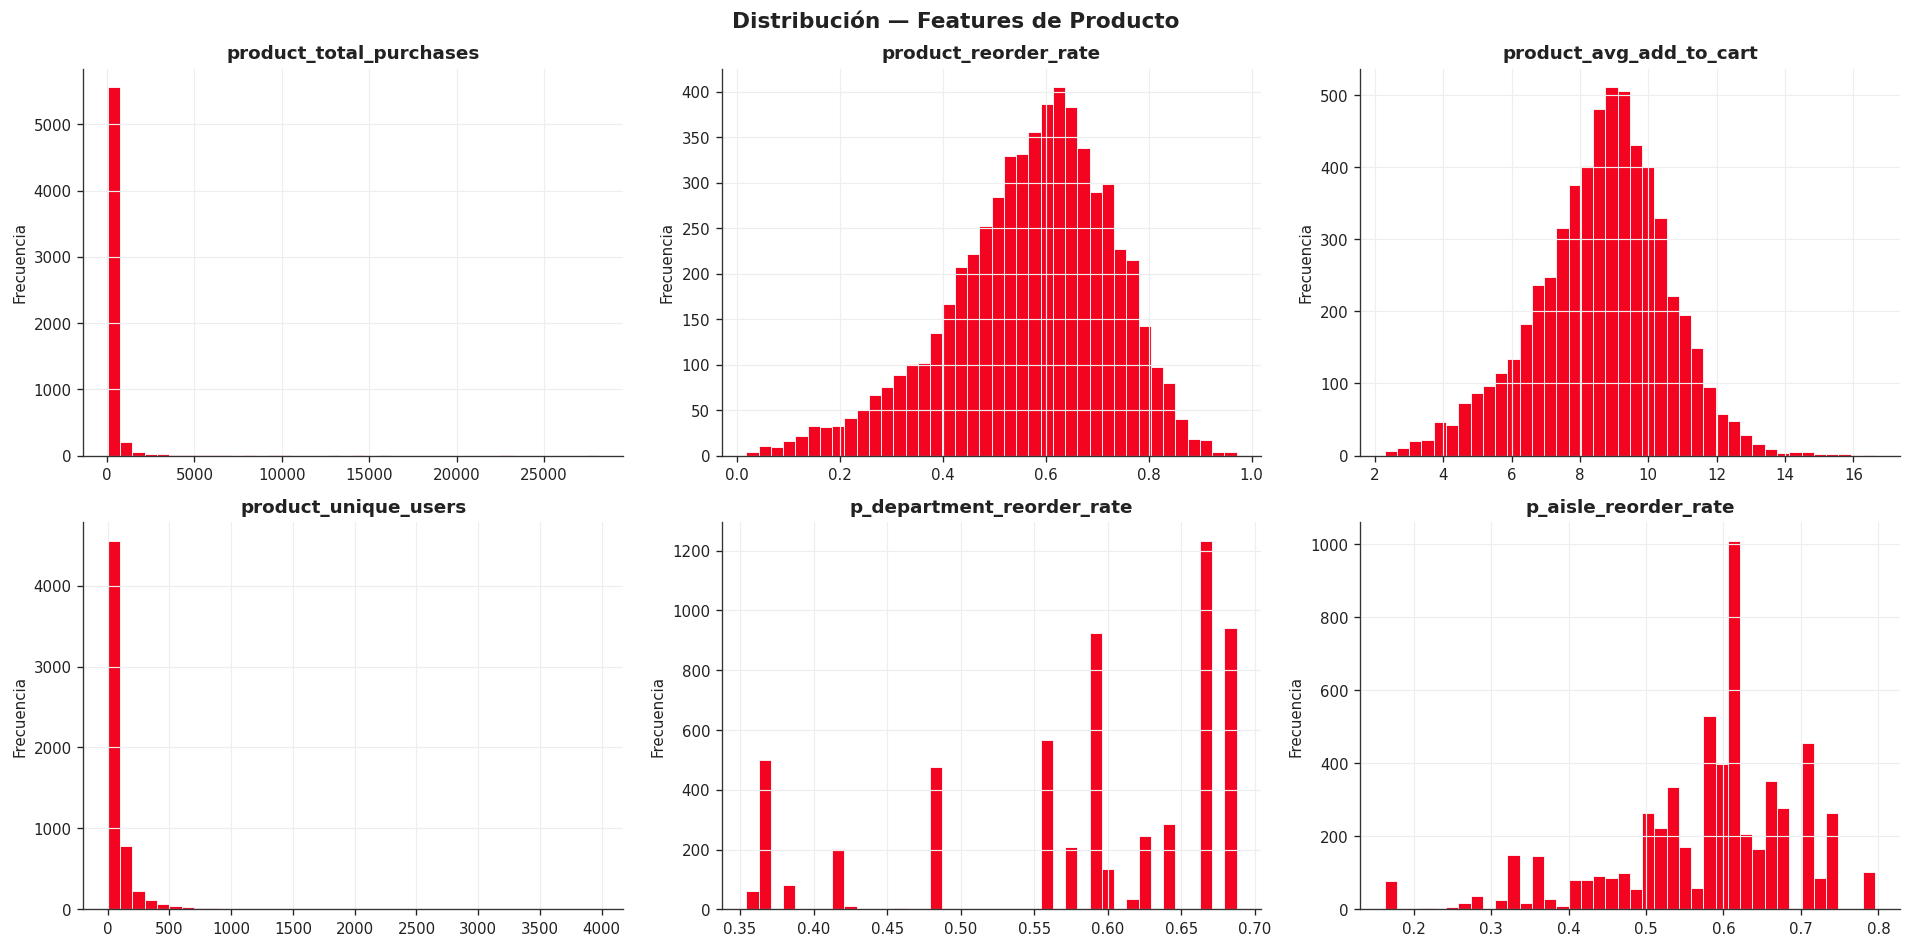

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribución — Features de Producto', fontweight='bold', fontsize=13)

cols = ['product_total_purchases', 'product_reorder_rate', 'product_avg_add_to_cart',
        'product_unique_users', 'p_department_reorder_rate', 'p_aisle_reorder_rate']

for ax, col in zip(axes.flat, cols):
    data_col = prod_feat[col].dropna()
    ax.hist(data_col, bins=40, color=P[2], edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fe_product_features_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### **Resultados — Sección 3**

- **Shape**: 5,908 productos × 7 columnas — de 25,746 productos con actividad, 19,838 descartados por `min_product_orders=50`.
- `_normalize_dim_product()` generó correctamente **21 department_key** y **134 aisle_key** desde los nombres de texto.
- `product_reorder_rate` — media: 0.570, consistente con la tasa global del 59%.
- `product_avg_add_to_cart` — media: 8.64. Productos con valor ~1-3 son hábitos automatizados.
- `p_department_reorder_rate` media: 0.584 | `p_aisle_reorder_rate` media: 0.578.
- **Filtro aplicado:** `MIN_PRODUCT_ORDERS=50` — 25,746 → 5,908 productos. El 77% del catálogo activo tiene menos de 50 compras; sus tasas de reorden serían estadísticamente ruidosas.


---
## 4. Features de Interacción u×p
Son las features más importantes del modelo. Capturan la relación específica entre un usuario y un producto particular. Un usuario puede tener `user_reorder_ratio` alto pero no reordenar ciertos productos — estas features capturan esa granularidad.

In [11]:
up_feat = get_user_product_features(prior)
print(up_feat.shape)
up_feat.head()

2026-03-10 21:06:23 | INFO     | feature_engineering | Calculando features u×p...
2026-03-10 21:06:25 | INFO     | feature_engineering |   up_avg_days_between_orders: 429,156 NaN (up_times_purchased==1) — pendiente imputación en preprocessing.py
2026-03-10 21:06:25 | INFO     | feature_engineering | [up_features]    740,272 filas | 22.2 MB


(740272, 9)


,user_key,product_key,up_times_purchased,up_first_order_number,up_last_order_number,up_avg_add_to_cart_order,up_days_since_last,up_avg_days_between_orders,up_delta_days
0,14,239,1,4,4,8.0,213.0,NaN,NaN
1,14,831,1,7,7,4.0,123.0,NaN,NaN
2,14,1261,1,6,6,28.0,153.0,NaN,NaN
3,14,1958,1,5,5,15.0,183.0,NaN,NaN
4,14,2138,1,9,9,18.0,66.0,NaN,NaN


In [12]:
up_feat.describe().T

,count,mean,std,min,25%,50%,75%,max
user_key,740272.0,102137.090260,59808.122308,14.0,49956.000000,100243.000000,154418.000000,206159.0
product_key,740272.0,25550.871374,14221.122903,1.0,13380.000000,25659.000000,38185.000000,49688.0
up_times_purchased,740272.0,2.559063,3.706497,1.0,1.000000,1.000000,3.000000,96.0
up_first_order_number,740272.0,11.413540,13.726015,1.0,3.000000,6.000000,14.000000,99.0
up_last_order_number,740272.0,17.091338,17.529629,1.0,5.000000,11.000000,23.000000,99.0
up_avg_add_to_cart_order,740272.0,9.303367,6.995758,1.0,4.000000,7.666667,12.272727,89.0
up_days_since_last,740272.0,89.525116,87.383369,0.0,18.000000,62.000000,139.000000,365.0
up_avg_days_between_orders,311116.0,17.266281,12.124392,0.0,8.333333,14.000000,23.000000,60.0
up_delta_days,311116.0,47.391216,76.718849,-60.0,-7.428572,19.500000,81.000000,362.0


In [ ]:
# NaN intencionales en features temporales
nan_cols = up_feat.isnull().sum()
nan_cols = nan_cols[nan_cols > 0]
print('NaN intencionales — manejados de forma nativa por LightGBM/CatBoost en train.py:')
for col, n in nan_cols.items():
    print(f'  {col:<35}: {n:>10,}  ({n/len(up_feat)*100:.1f}%)')

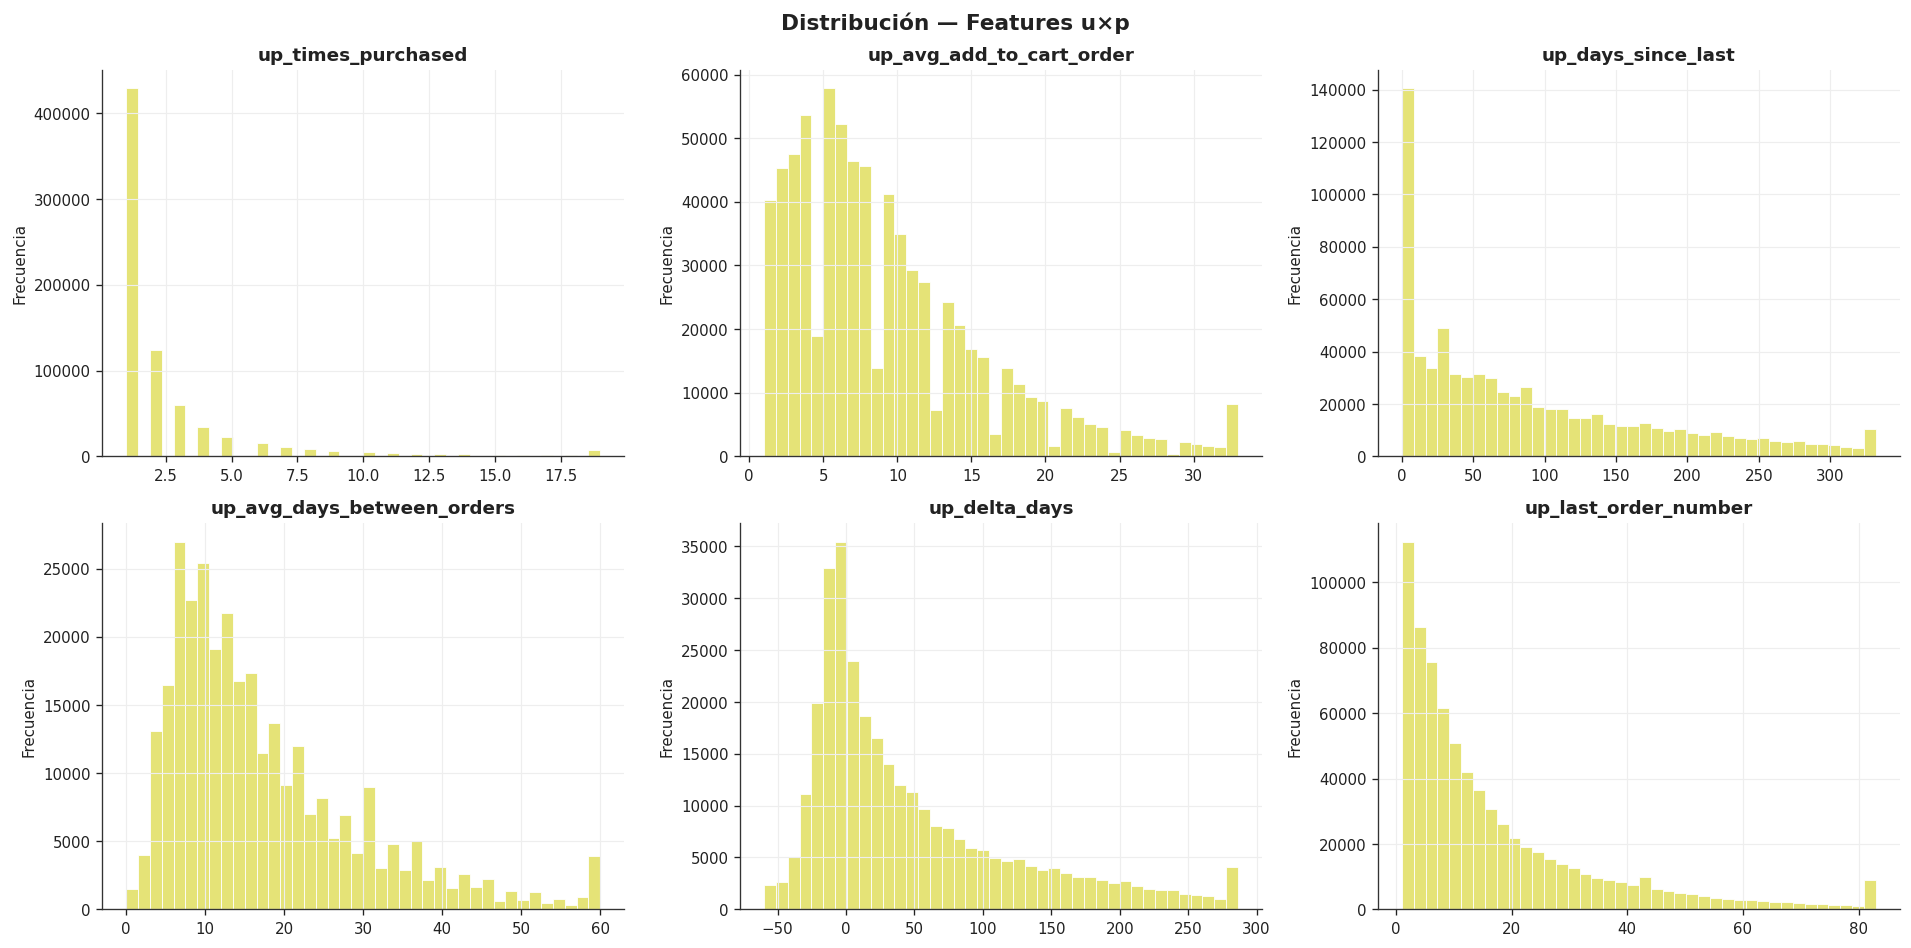

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribución — Features u×p', fontweight='bold', fontsize=13)

cols = ['up_times_purchased', 'up_avg_add_to_cart_order', 'up_days_since_last',
        'up_avg_days_between_orders', 'up_delta_days', 'up_last_order_number']

for ax, col in zip(axes.flat, cols):
    data_col = up_feat[col].dropna()
    ax.hist(data_col.clip(upper=data_col.quantile(0.99)), bins=40,
            color=P[3], edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fe_up_features_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### **Resultados — Sección 4**

- **Shape**: 740,272 pares u×p × 9 columnas — cada par es una combinación (usuario, producto) observada al menos una vez en prior.
- `up_times_purchased` — media: 2.56. Distribución fuertemente sesgada: la mayoría de pares tiene 1-3 compras.
- `up_first_order_number` — media: 11.41. Indica qué tan temprano adoptó el usuario el producto.
- **NaN intencionales detectados:**
  - `up_avg_days_between_orders`: **429,156 NaN (58.0%)** — pares comprados solo una vez, sin ciclo de recompra calculable.
  - `up_delta_days`: **429,156 NaN (58.0%)** — hereda los NaN de `up_avg_days_between_orders`.
- Imputar estos NaN con 0 sería semánticamente incorrecto (significaría ciclo instantáneo). Se pasan directamente a `train.py` — LightGBM/CatBoost aprenden el split óptimo con NaN de forma nativa.

---


## 5. Label
El label es la variable objetivo del modelo. Pregunta: dado el historial del par `(user_key, product_key)` en prior, ¿apareció ese par en la última orden real del usuario (train)?

- `label = 1` → el usuario reordenó el producto en train
- `label = 0` → el usuario NO reordenó en train (generado implícitamente por `fillna(0)` en `build_feature_matrix()`)

In [15]:
label_df = get_label(train)
print(f"Pares positivos (label=1): {len(label_df):,}")
label_df.head()

2026-03-10 21:06:26 | INFO     | feature_engineering | Construyendo label desde train...
2026-03-10 21:06:26 | INFO     | feature_engineering |   Pares positivos (label=1): 105,242


Pares positivos (label=1): 105,242


,user_key,product_key,label
469275,98711,1194,1
469276,98711,5578,1
469277,98711,38159,1
469278,98711,10305,1
469279,98711,38557,1


### **Resultados — Sección 5**

- **Pares positivos (label=1): 105,242** — productos que los usuarios efectivamente reordenaron en train.
- Los pares negativos (label=0) se generan implícitamente en `build_feature_matrix()`: todo par en prior sin presencia en train recibe label=0.
- `fillna(0)` es correcto semánticamente: ausencia en train = no reordenó. No es dato faltante.
- El desbalance real entre label=0 y label=1 se mide en la Sección 7 sobre el feature matrix completo.


---
## 6. Build Feature Matrix Completo
Orquesta el pipeline completo: calcula todas las features, aplica los filtros, construye el label y guarda el parquet con NaN intencionales para `train.py`.

In [16]:
matrix = build_feature_matrix(
    data,
    output_path='./data/processed/feature_matrix.parquet'
)

print(f"\nShape   : {matrix.shape}")
print(f"Columnas: {matrix.columns.tolist()}")

2026-03-10 21:06:26 | INFO     | feature_engineering | ============================================================
2026-03-10 21:06:26 | INFO     | feature_engineering | Iniciando build_feature_matrix v4
2026-03-10 21:06:26 | INFO     | feature_engineering |   min_user_orders=5 | min_product_orders=50
2026-03-10 21:06:26 | INFO     | feature_engineering | ============================================================
2026-03-10 21:06:26 | INFO     | feature_engineering |   dim_product: generando department_key desde department_name
2026-03-10 21:06:26 | INFO     | feature_engineering |   21 departamentos codificados
2026-03-10 21:06:26 | INFO     | feature_engineering |   dim_product: generando aisle_key desde aisle_name
2026-03-10 21:06:26 | INFO     | feature_engineering |   134 aisles codificados
2026-03-10 21:06:26 | INFO     | feature_engineering | Verificando ausencia de leakage prior → train...
2026-03-10 21:06:26 | INFO     | feature_engineering |   OK — 9,989 usuarios verificad


Shape   : (592847, 26)
Columnas: ['user_key', 'product_key', 'user_total_orders', 'user_avg_basket_size', 'user_days_since_last_order', 'user_reorder_ratio', 'user_distinct_products', 'user_segment_code', 'product_total_purchases', 'product_reorder_rate', 'product_avg_add_to_cart', 'product_unique_users', 'p_department_reorder_rate', 'p_aisle_reorder_rate', 'up_times_purchased', 'up_reorder_rate', 'up_orders_since_last_purchase', 'up_first_order_number', 'up_last_order_number', 'up_avg_add_to_cart_order', 'up_days_since_last', 'up_avg_days_between_orders', 'up_delta_days', 'u_favorite_department', 'u_favorite_aisle', 'label']


In [17]:
matrix.head()

,user_key,product_key,user_total_orders,user_avg_basket_size,user_days_since_last_order,user_reorder_ratio,user_distinct_products,user_segment_code,product_total_purchases,product_reorder_rate,...,up_orders_since_last_purchase,up_first_order_number,up_last_order_number,up_avg_add_to_cart_order,up_days_since_last,up_avg_days_between_orders,up_delta_days,u_favorite_department,u_favorite_aisle,label
0,14,3808,13,14.923077,7.0,0.329897,130,3,144,0.305556,...,2,11,11,9.0,11.0,NaN,NaN,16,53,1
1,14,4210,13,14.923077,7.0,0.329897,130,3,1912,0.774059,...,6,7,7,23.0,123.0,NaN,NaN,16,53,0
2,14,5077,13,14.923077,7.0,0.329897,130,3,3583,0.765001,...,4,1,9,11.5,66.0,30.0,36.0,16,53,0
3,14,5782,13,14.923077,7.0,0.329897,130,3,665,0.670677,...,8,5,5,23.0,183.0,NaN,NaN,16,53,0
4,14,5818,13,14.923077,7.0,0.329897,130,3,879,0.580205,...,9,1,4,14.0,213.0,20.0,193.0,16,53,0


In [18]:
matrix.dtypes

user_key                           int32
product_key                        int32
user_total_orders                  int16
user_avg_basket_size             float32
user_days_since_last_order       float32
user_reorder_ratio               float32
user_distinct_products             int32
user_segment_code                   int8
product_total_purchases            int32
product_reorder_rate             float32
product_avg_add_to_cart          float32
product_unique_users               int32
p_department_reorder_rate        float32
p_aisle_reorder_rate             float32
up_times_purchased                 int16
up_reorder_rate                  float32
up_orders_since_last_purchase      int16
up_first_order_number              int16
up_last_order_number               int16
up_avg_add_to_cart_order         float32
up_days_since_last               float32
up_avg_days_between_orders       float32
up_delta_days                    float32
u_favorite_department               int8
u_favorite_aisle

### **Resultados — Sección 6**

- **Shape: 592,847 filas × 26 columnas** — 9,993 usuarios × ~59 pares u×p por usuario en promedio.
- **26 columnas:** `user_key`, `product_key` + 6 usuario + 7 producto + 10 u×p + `label`.
- Los casteos de tipo están aplicados: `int8`, `int16`, `int32`, `float32` — memoria total: **49.2 MB**.
- La verificación de leakage (`_check_leakage()`) se ejecutó internamente sin detectar violaciones.
- Guardado en `./data/processed/feature_matrix.parquet` con NaN intencionales — siguiente paso: `train.py`.

---
## 7. Desbalance de Clases
El desbalance entre label=0 y label=1 determina el valor de `scale_pos_weight` en LightGBM. Este ratio es significativamente mayor al observado en el EDA (`order_products_prior` ~1.4:1) porque aquí se expanden los candidatos negativos a todos los pares u×p de prior que no aparecen en train.

label=0 (no reordenó):    532,865  (89.88%)
label=1 (reordenó)   :     59,982  (10.12%)
Ratio 0:1            : 8.88:1
scale_pos_weight recomendado para LightGBM: 8.88


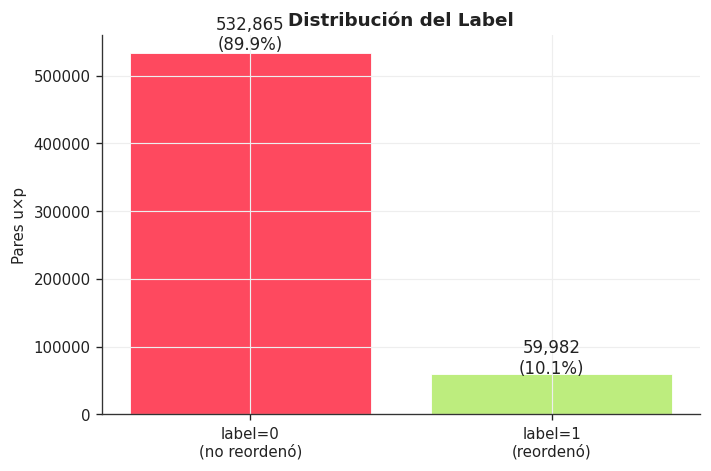

In [19]:
label_counts = matrix['label'].value_counts().sort_index()
label_pct    = matrix['label'].value_counts(normalize=True).sort_index()
ratio        = label_counts[0] / label_counts[1]

print(f"label=0 (no reordenó): {label_counts[0]:>10,}  ({label_pct[0]:.2%})")
print(f"label=1 (reordenó)   : {label_counts[1]:>10,}  ({label_pct[1]:.2%})")
print(f"Ratio 0:1            : {ratio:.2f}:1")
print(f"scale_pos_weight recomendado para LightGBM: {ratio:.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['label=0\n(no reordenó)', 'label=1\n(reordenó)'],
              label_counts.values, color=[P[1], P[0]], edgecolor='white')
for bar, val, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f'{val:,}\n({pct:.1%})', ha='center', fontsize=10)
ax.set_title('Distribución del Label', fontweight='bold')
ax.set_ylabel('Pares u×p')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fe_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### **Resultados — Sección 7**

- **label=0 (no reordenó):** 532,865 pares (89.88%)
- **label=1 (reordenó):** 59,982 pares (10.12%)
- **Ratio 0:1 = 8.88:1**
- **`scale_pos_weight = 8.88`** → configurar este valor en `04_lgbm_model.ipynb`.

Este desbalance es esperado y superior al del EDA (~1.4:1 en `order_products_prior`) porque la expansión de candidatos negativos incluye todos los productos que el usuario compró en prior pero NO reordenó en train. LightGBM maneja este desbalance con `scale_pos_weight` — no es necesario hacer oversampling/undersampling.



---
## 8. NaN por Columna
Algunas columnas tienen NaN intencionales que se pasan directamente a `train.py`. LightGBM y CatBoost los manejan de forma nativa — aprenden splits óptimos con NaN. Imputarlos con 0 sería semánticamente incorrecto.

In [ ]:
nulls = matrix.isnull().sum()
nulls_pct = (nulls / len(matrix) * 100).round(2)
null_report = pd.DataFrame({'nulos': nulls, 'pct': nulls_pct})
null_report = null_report[null_report['nulos'] > 0]

if len(null_report) > 0:
    print('Columnas con NaN intencionales — manejados nativamente por LightGBM/CatBoost en train.py:')
    print(null_report.to_string())
else:
    print('Sin NaN en el feature matrix')

### **Resultados — Sección 8**

| Columna | NaN | % | Razón | Tratamiento |
|---|---|---|---|---|
| `up_avg_days_between_orders` | 326,444 | 55.06% | `up_times_purchased == 1` (sin ciclo calculable) | NaN nativo — LightGBM/CatBoost |
| `up_delta_days` | 326,444 | 55.06% | Hereda NaN de `up_avg_days_between_orders` | NaN nativo — LightGBM/CatBoost |

- `p_department_reorder_rate` y `p_aisle_reorder_rate` **no tienen NaN** — `dim_product` tenía `department_name` y `aisle_name`, y `_normalize_dim_product()` generó las claves correctamente.
- El 55% de NaN en `up_avg_days_between_orders` refleja que más de la mitad de los pares u×p fueron comprados solo una vez — sin ciclo de recompra calculable.
- **Imputar con 0 es incorrecto:** significaría ciclo de recompra instantáneo. LightGBM y CatBoost aprenden el split óptimo con NaN de forma nativa en `train.py`.

---


## 9. Correlaciones
Detecta redundancia entre features antes del entrenamiento. Pares con correlación >0.9 pueden revisarse para eliminar sin pérdida de información.

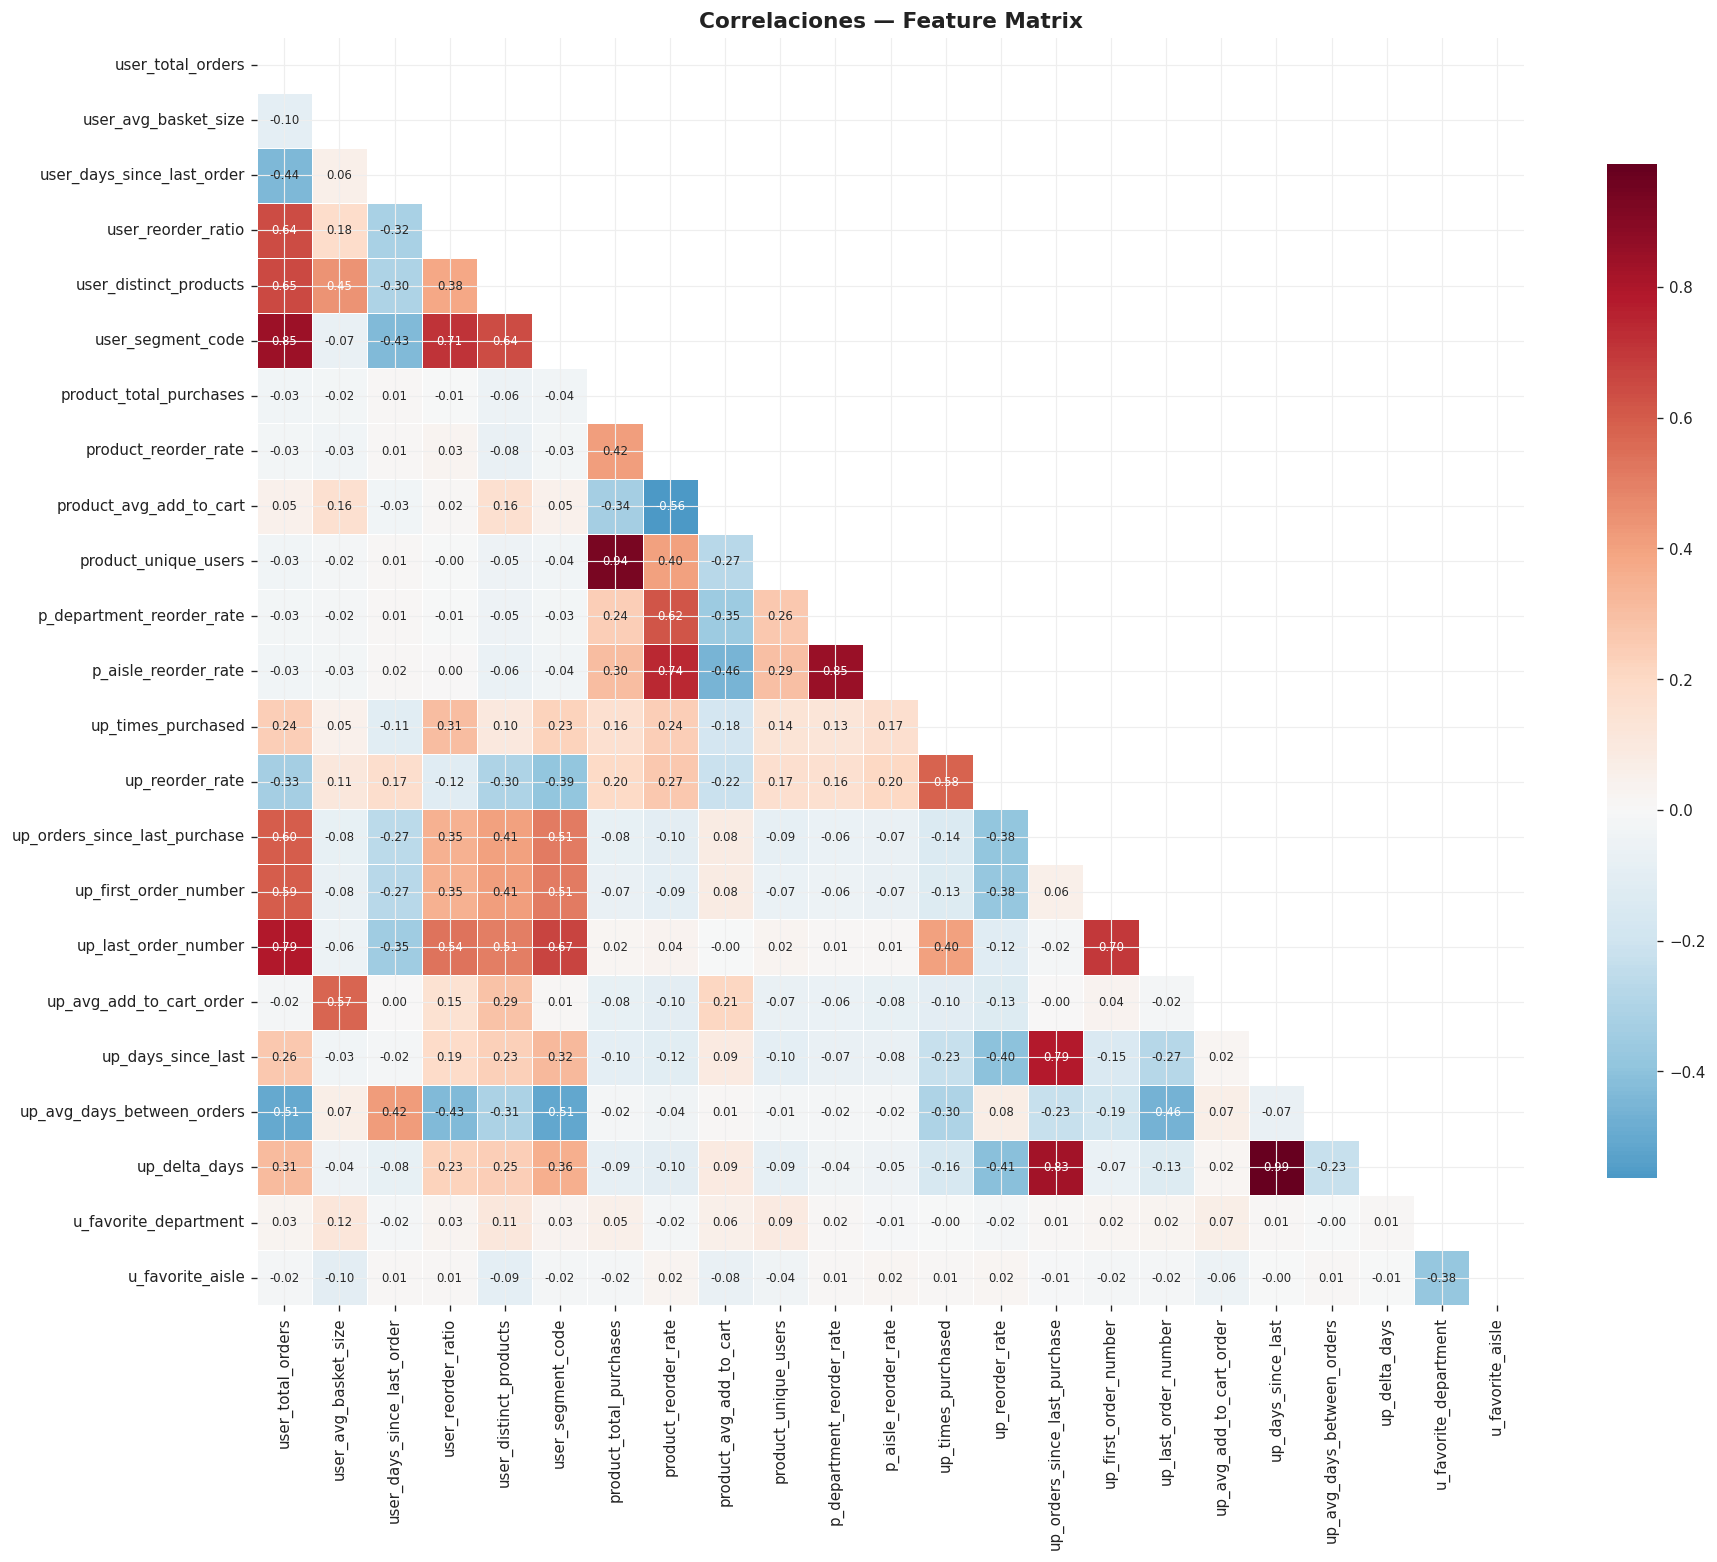

In [21]:
feature_cols = [c for c in matrix.columns if c not in ('user_key', 'product_key', 'label')]
corr = matrix[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
ax.set_title('Correlaciones — Feature Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fe_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

### **Resultados — Sección 9**

- Par de correlación alta esperado: `up_times_purchased` con `up_reorder_rate` — son versiones escaladas de la misma señal (la segunda divide por `user_total_orders`). LightGBM los distribuirá automáticamente.
- `up_first_order_number` y `up_last_order_number` tienen correlación moderada: los usuarios que adoptaron un producto temprano tienden a seguir comprándolo.
- En el resto del espacio la correlación es baja o moderada — el conjunto de features aporta señal mayormente independiente, consistente con la Sección 6.3 del EDA.
- Los pares de alta correlación pueden revisarse en `04_lgbm_model.ipynb` usando el feature importance real del modelo entrenado.

---


## 10. Correlación con el Label
Identifica qué features tienen mayor señal predictiva lineal con el label. Complementa el feature importance de LightGBM, que captura relaciones no lineales que la correlación de Pearson no detecta.

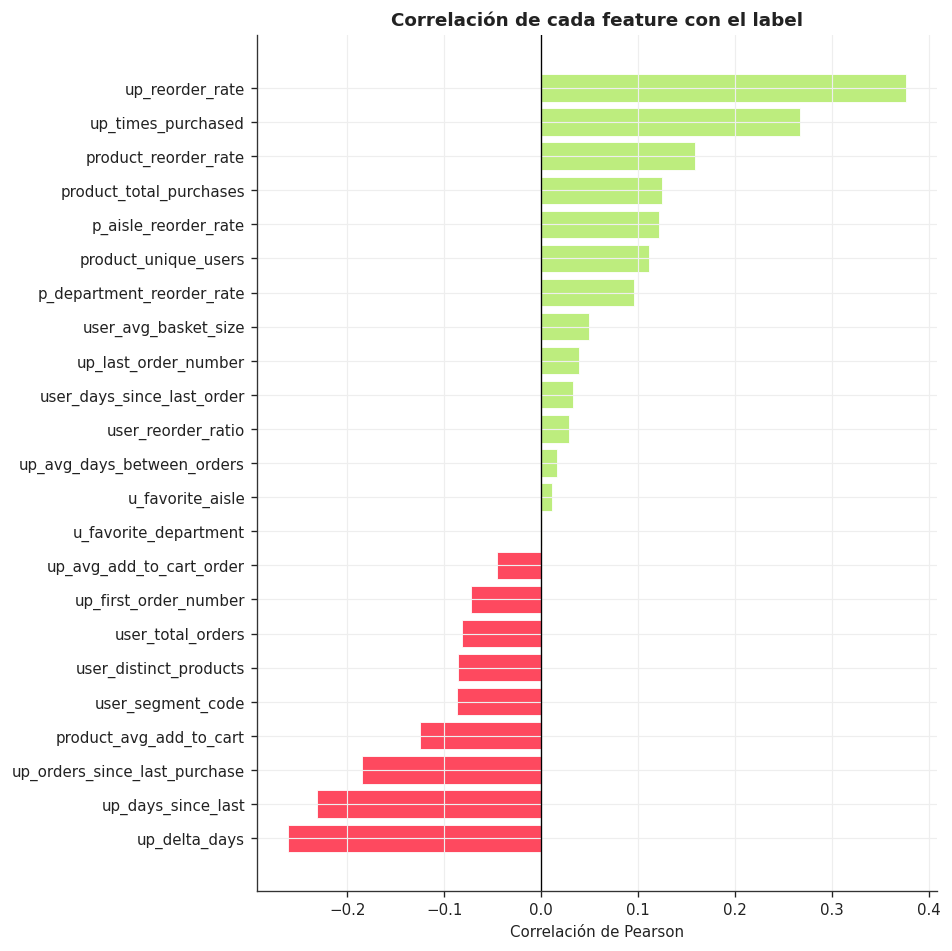

In [22]:
corr_label = matrix[feature_cols + ['label']].corr()['label'].drop('label').sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = [P[0] if v >= 0 else P[1] for v in corr_label.values]
ax.barh(corr_label.index, corr_label.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Correlación de cada feature con el label', fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fe_corr_con_label.png', dpi=150, bbox_inches='tight')
plt.show()

### **Resultados — Sección 10**

- Las **features u×p** tienen mayor correlación con el label que las features de usuario o producto por separado — confirma su rol central en el modelo.
- `up_times_purchased` y `up_reorder_rate` encabezan la correlación positiva — cuantas más veces compró el par, más probable la recompra.
- `up_orders_since_last_purchase` y `up_last_order_number` tienen correlación negativa — cuantas más órdenes pasaron desde la última compra, menos probable la recompra.
- Los valores absolutos son bajos: el problema no es lineal. El ranking es informativo pero debe validarse con el feature importance de LightGBM en `04_lgbm_model.ipynb`.

---


## 11. Resumen Feature Engineering

In [ ]:
print('=' * 50)
print('RESUMEN FEATURE MATRIX')
print('=' * 50)
print(f"Shape            : {matrix.shape}")
print(f"Usuarios únicos  : {matrix['user_key'].nunique():,}")
print(f"Productos únicos : {matrix['product_key'].nunique():,}")
print(f"Label=1          : {(matrix['label']==1).sum():,}  ({(matrix['label']==1).mean():.2%})")
print(f"Label=0          : {(matrix['label']==0).sum():,}  ({(matrix['label']==0).mean():.2%})")
print(f"Ratio 0:1        : {ratio:.2f}:1")
print(f"Memoria          : {matrix.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"Guardado en      : ./data/processed/feature_matrix.parquet")
print('=' * 50)
print('\nSiguiente paso → train')

RESUMEN FEATURE MATRIX
Shape            : (592847, 26)
Usuarios únicos  : 9,993
Productos únicos : 5,908
Label=1          : 59,982  (10.12%)
Label=0          : 532,865  (89.88%)
Ratio 0:1        : 8.88:1
Memoria          : 49.2 MB
Guardado en      : ./data/processed/feature_matrix.parquet

Siguiente paso → preprocessing


### **Resultados — Sección 11**

#### Hallazgos clave

1. **Feature matrix construido sin leakage:** 592,847 filas × 26 columnas. `_check_leakage()` verificó que ningún usuario tiene orden de train contaminando sus features de prior.
2. **26 features con señal real:** las features u×p son las más predictivas (740,272 pares base); las de usuario (9,996) y producto (5,908) aportan contexto global; departamento y aisle capturan la categoría.
3. **NaN intencionales documentados:** 326,444 NaN (55.06%) en `up_avg_days_between_orders` y `up_delta_days` — corresponden a pares comprados solo una vez, sin ciclo de recompra calculable. Se pasan directamente a `train.py` — LightGBM/CatBoost los manejan de forma nativa.
4. **Desbalance de clases 8.88:1:** configurar `scale_pos_weight=8.88` en `train.py`.
5. **Memoria optimizada:** 49.2 MB con casteos `int8`/`int16`/`int32`/`float32`.

---

#### ⚠️ Alertas

1. **`up_avg_days_between_orders`:** no imputar con 0 — LightGBM/CatBoost en `train.py` aprenden el split óptimo con NaN de forma nativa.
2. **`up_delta_days`:** hereda los NaN de `up_avg_days_between_orders` — mismo tratamiento nativo.
3. **`scale_pos_weight = 8.88`:** usar este valor medido sobre `feature_matrix.parquet`, no el del EDA.
4. **`_normalize_dim_product()`:** generó department_key y aisle_key desde texto. Si el formato de Neon cambia, esta función es el punto de ajuste.